<a href="https://colab.research.google.com/github/AJPardhiv/ML-Lab/blob/main/Week_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PART A: MANUAL CALCULATIONS

1. Sample Dataset:
   Features: [Age, Income]
   Target: Buy

   Data:
 Age  Income  Buy
   0       0    0
   0       0    0
   1       0    0
   2       0    0
   2       1    1
   2       1    1
   1       1    1
   0       1    0
   2       0    1
   0       1    1

2. Gini Impurity Calculation:
   Formula: 1 - sum(p_i^2)
   Total: 10, Yes: 5, No: 5
   P(Yes)=0.50, P(No)=0.50
   Gini = 1 - (0.50^2 + 0.50^2) = 0.5000

3. Entropy Calculation:
   Formula: -sum(p_i * log2(p_i))
   Entropy = -[0.50*log2(0.50) + 0.50*log2(0.50)] = 1.0000

4. Example Split: Age <= 1
   Left branch (Age<=1): [np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1)]
   Right branch (Age>1): [np.int64(0), np.int64(1), np.int64(1), np.int64(1)]
   Gini(left) = 0.4444
   Gini(right) = 0.3750
   Weighted average = 0.4167
   Information Gain = 0.5000 - 0.4167 = 0.0833

PART B: IRIS DATASET ANALYSIS

1. Load Iris Dataset
   Samples: 150
   Features used: ['sepal le

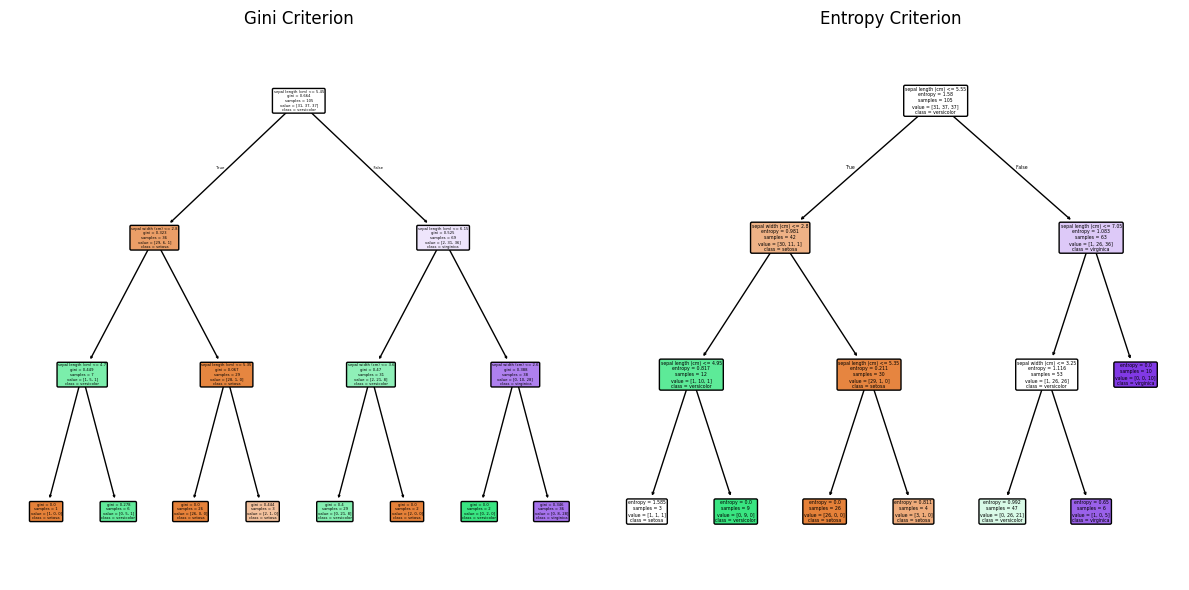


6. Feature Importance
   Gini Importance:
     sepal length (cm): 0.723
     sepal width (cm): 0.277

   Entropy Importance:
     sepal length (cm): 0.686
     sepal width (cm): 0.314

7. Test Pruning (max_depth)
   Depth | Gini  Acc  | Entropy  Acc 
   ------------------------------
       1 |    0.644 |      0.667
       2 |    0.756 |      0.711
       3 |    0.756 |      0.667
       4 |    0.756 |      0.800
       5 |    0.756 |      0.756


In [1]:
# EXP-5 (IN-LAB): Decision Trees using Gini & Entropy (Manual + scikit-learn CART) + Overfitting (max_depth)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# -------------------------------
# PART A: SIMPLE MANUAL CALCULATIONS
# -------------------------------
print("=" * 60)
print("PART A: MANUAL CALCULATIONS")
print("=" * 60)

# 1. Create simple dataset
print("\n1. Sample Dataset:")
print("   Features: [Age, Income]")
print("   Target: Buy")
print("\n   Data:")

data = [
    [0, 0, 0],
    [0, 0, 0],
    [1, 0, 0],
    [2, 0, 0],
    [2, 1, 1],
    [2, 1, 1],
    [1, 1, 1],
    [0, 1, 0],
    [2, 0, 1],
    [0, 1, 1]
]
df = pd.DataFrame(data, columns=["Age", "Income", "Buy"])
print(df.to_string(index=False))

# 2. Calculate Gini impurity manually
print("\n2. Gini Impurity Calculation:")
print("   Formula: 1 - sum(p_i^2)")

labels = df["Buy"].values
n_total = len(labels)
n_yes = sum(labels)
n_no = n_total - n_yes

p_yes = n_yes / n_total
p_no = n_no / n_total

gini = 1 - (p_yes**2 + p_no**2)

print(f"   Total: {n_total}, Yes: {n_yes}, No: {n_no}")
print(f"   P(Yes)={p_yes:.2f}, P(No)={p_no:.2f}")
print(f"   Gini = 1 - ({p_yes:.2f}^2 + {p_no:.2f}^2) = {gini:.4f}")

# 3. Calculate Entropy manually
print("\n3. Entropy Calculation:")
print("   Formula: -sum(p_i * log2(p_i))")

entropy = 0
if p_yes > 0:
    entropy -= p_yes * np.log2(p_yes)
if p_no > 0:
    entropy -= p_no * np.log2(p_no)

print(f"   Entropy = -[{p_yes:.2f}*log2({p_yes:.2f}) + {p_no:.2f}*log2({p_no:.2f})] = {entropy:.4f}")

# 4. Simple split example
print("\n4. Example Split: Age <= 1")

left = df[df["Age"] <= 1]["Buy"].values
right = df[df["Age"] > 1]["Buy"].values

def simple_gini(y):
    if len(y) == 0:
        return 0
    p1 = sum(y) / len(y)
    p0 = 1 - p1
    return 1 - (p1**2 + p0**2)

gini_left = simple_gini(left)
gini_right = simple_gini(right)

weighted_gini = (len(left) / n_total) * gini_left + (len(right) / n_total) * gini_right
gain = gini - weighted_gini

print(f"   Left branch (Age<=1): {list(left)}")
print(f"   Right branch (Age>1): {list(right)}")
print(f"   Gini(left) = {gini_left:.4f}")
print(f"   Gini(right) = {gini_right:.4f}")
print(f"   Weighted average = {weighted_gini:.4f}")
print(f"   Information Gain = {gini:.4f} - {weighted_gini:.4f} = {gain:.4f}")

# -------------------------------
# PART B: SIMPLE IRIS DATASET ANALYSIS
# -------------------------------
print("\n" + "=" * 60)
print("PART B: IRIS DATASET ANALYSIS")
print("=" * 60)

# 1. Load data
print("\n1. Load Iris Dataset")
iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names[:2]  # Use only 2 features for simplicity
target_names = iris.target_names

print(f"   Samples: {len(X)}")
print(f"   Features used: {feature_names}")
print(f"   Classes: {target_names}")

# 2. Split data
X_simple = X[:, :2]
X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.3, random_state=42
)

print("\n2. Data Split")
print(f"   Train: {len(X_train)} samples")
print(f"   Test: {len(X_test)} samples")

# 3. Train with Gini and Entropy
print("\n3. Train Decision Trees")
dt_gini = DecisionTreeClassifier(criterion="gini", random_state=42, max_depth=3)
dt_gini.fit(X_train, y_train)

dt_entropy = DecisionTreeClassifier(criterion="entropy", random_state=42, max_depth=3)
dt_entropy.fit(X_train, y_train)

# 4. Evaluate
print("\n4. Model Performance")
y_pred_gini = dt_gini.predict(X_test)
y_pred_entropy = dt_entropy.predict(X_test)

acc_gini = accuracy_score(y_test, y_pred_gini)
acc_entropy = accuracy_score(y_test, y_pred_entropy)

print(f"   Gini Accuracy: {acc_gini:.3f}")
print(f"   Entropy Accuracy: {acc_entropy:.3f}")

# 5. Visualize Trees
print("\n5. Visualize Trees")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

plot_tree(
    dt_gini,
    feature_names=feature_names,
    class_names=target_names,
    filled=True,
    rounded=True,
    ax=ax1
)
ax1.set_title("Gini Criterion")

plot_tree(
    dt_entropy,
    feature_names=feature_names,
    class_names=target_names,
    filled=True,
    rounded=True,
    ax=ax2
)
ax2.set_title("Entropy Criterion")

plt.tight_layout()
plt.savefig("simple_trees.png", dpi=100, bbox_inches="tight")
plt.show()

# 6. Feature importance
print("\n6. Feature Importance")
print("   Gini Importance:")
for name, imp in zip(feature_names, dt_gini.feature_importances_):
    print(f"     {name}: {imp:.3f}")

print("\n   Entropy Importance:")
for name, imp in zip(feature_names, dt_entropy.feature_importances_):
    print(f"     {name}: {imp:.3f}")

# 7. Simple pruning test with max_depth
print("\n7. Test Pruning (max_depth)")
depths = [1, 2, 3, 4, 5]
print("   Depth | Gini  Acc  | Entropy  Acc ")
print("   " + "-" * 30)

for depth in depths:
    dt_g = DecisionTreeClassifier(criterion="gini", max_depth=depth, random_state=42)
    dt_g.fit(X_train, y_train)
    acc_g = accuracy_score(y_test, dt_g.predict(X_test))

    dt_e = DecisionTreeClassifier(criterion="entropy", max_depth=depth, random_state=42)
    dt_e.fit(X_train, y_train)
    acc_e = accuracy_score(y_test, dt_e.predict(X_test))

    print(f"   {depth:5d} | {acc_g:8.3f} | {acc_e:10.3f}")

**POST LAB**

POST-LAB 1: MANUAL INFORMATION GAIN (ENTROPY)
Split: Age <= 1
Information Gain (Entropy) = 0.1245

POST-LAB 2: COMPARE MAX_DEPTH VALUES (IRIS)
max_depth=   1 -> Accuracy=0.644
max_depth=   2 -> Accuracy=0.756
max_depth=   3 -> Accuracy=0.756
max_depth=   4 -> Accuracy=0.756
max_depth=   5 -> Accuracy=0.756
max_depth=None -> Accuracy=0.667

POST-LAB 3: COST COMPLEXITY POST-PRUNING (ccp_alpha)
alpha		accuracy	leaves
0.000000	0.667		40
0.002116	0.667		37
0.002381	0.667		35
0.003175	0.689		34
0.004233	0.711		31
0.005556	0.711		28
0.006349	0.711		26
0.007222	0.733		22
0.007256	0.733		21
0.007937	0.733		19

Best alpha: 0.021832 | Best Accuracy: 0.800 | Leaves: 5


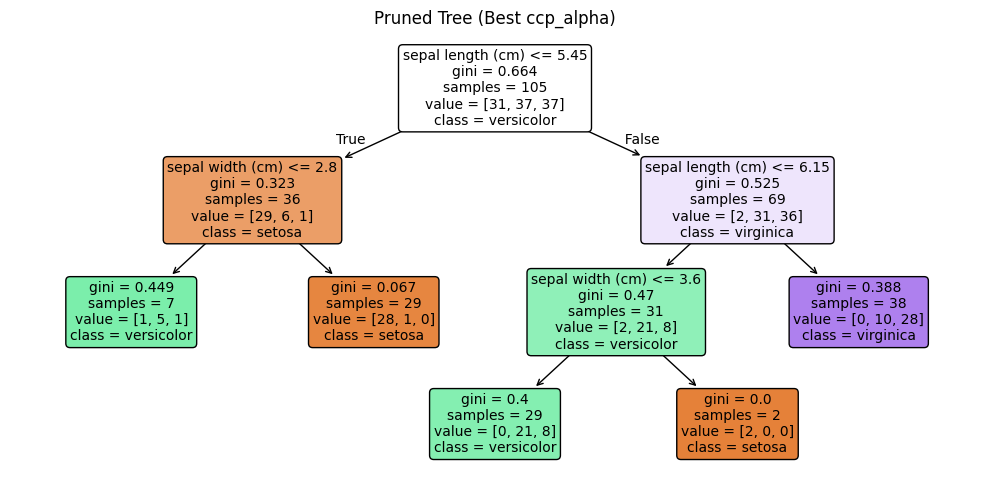

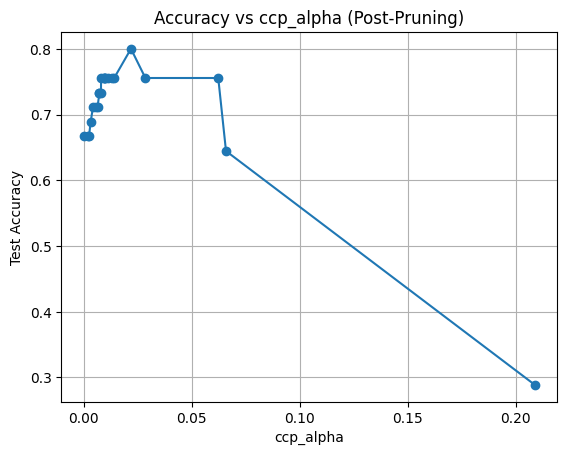


POST-LAB 4: DECISION TREE REGRESSOR
Regressor -> MSE=784.4979, R2=0.5322


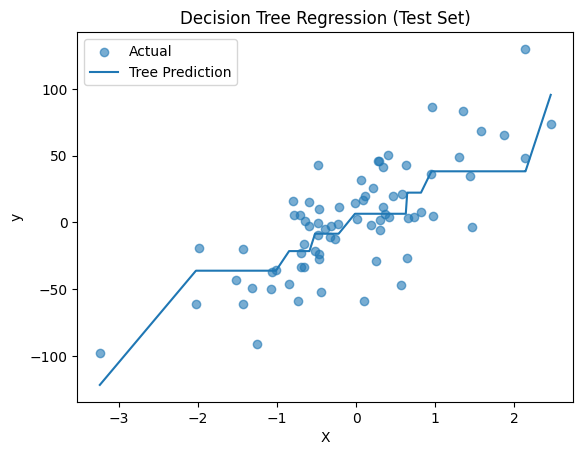


POST-LAB 5: EXPORT DECISION RULES
|--- sepal length (cm) <= 5.45
|   |--- sepal width (cm) <= 2.80
|   |   |--- class: 1
|   |--- sepal width (cm) >  2.80
|   |   |--- class: 0
|--- sepal length (cm) >  5.45
|   |--- sepal length (cm) <= 6.15
|   |   |--- sepal width (cm) <= 3.60
|   |   |   |--- class: 1
|   |   |--- sepal width (cm) >  3.60
|   |   |   |--- class: 0
|   |--- sepal length (cm) >  6.15
|   |   |--- class: 2



In [2]:
# EXP-5 (POST-LAB): Cost-Complexity Post-Pruning, Manual Information Gain Function,
#                   Compare max_depth, DecisionTreeRegressor, Export Decision Rules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, make_regression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score

# ---------------------------------------------------------
# 1) Function to manually calculate Information Gain
# ---------------------------------------------------------
# Title: Manual Information Gain (Entropy) for Any Split

def entropy_from_labels(y):
    """Entropy of a 0/1 label vector (or multi-class)."""
    if len(y) == 0:
        return 0.0
    values, counts = np.unique(y, return_counts=True)
    probs = counts / counts.sum()
    ent = 0.0
    for p in probs:
        if p > 0:
            ent -= p * np.log2(p)
    return ent

def information_gain_entropy(y_parent, y_left, y_right):
    """Information gain using entropy."""
    n = len(y_parent)
    if n == 0:
        return 0.0
    w_left = len(y_left) / n
    w_right = len(y_right) / n
    return entropy_from_labels(y_parent) - (w_left * entropy_from_labels(y_left) + w_right * entropy_from_labels(y_right))

# Example on a small dataset (same style as in-lab)
data = [
    [0, 0, 0],
    [0, 0, 0],
    [1, 0, 0],
    [2, 0, 0],
    [2, 1, 1],
    [2, 1, 1],
    [1, 1, 1],
    [0, 1, 0],
    [2, 0, 1],
    [0, 1, 1]
]
df = pd.DataFrame(data, columns=["Age", "Income", "Buy"])
y_parent = df["Buy"].values
y_left = df[df["Age"] <= 1]["Buy"].values
y_right = df[df["Age"] > 1]["Buy"].values

print("=" * 70)
print("POST-LAB 1: MANUAL INFORMATION GAIN (ENTROPY)")
print("=" * 70)
ig = information_gain_entropy(y_parent, y_left, y_right)
print("Split: Age <= 1")
print(f"Information Gain (Entropy) = {ig:.4f}")


# ---------------------------------------------------------
# 2) Compare Decision Tree with different max_depth values
# ---------------------------------------------------------
# Title: Compare Different max_depth Values (Classification on Iris)

print("\n" + "=" * 70)
print("POST-LAB 2: COMPARE MAX_DEPTH VALUES (IRIS)")
print("=" * 70)

iris = load_iris()
X = iris.data[:, :2]  # keep same simplicity (2 features)
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

depths = [1, 2, 3, 4, 5, None]
for d in depths:
    model = DecisionTreeClassifier(criterion="gini", max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"max_depth={str(d):>4} -> Accuracy={acc:.3f}")


# ---------------------------------------------------------
# 3) Post-pruning using Cost Complexity Pruning (ccp_alpha)
# ---------------------------------------------------------
# Title: Cost Complexity Post-Pruning (ccp_alpha)

print("\n" + "=" * 70)
print("POST-LAB 3: COST COMPLEXITY POST-PRUNING (ccp_alpha)")
print("=" * 70)

# Get pruning path (sequence of effective alphas)
base_tree = DecisionTreeClassifier(random_state=42)
path = base_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# Train trees for a set of alphas and evaluate
results = []
for a in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=a)
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    results.append((a, acc, clf.get_n_leaves()))

# Print a few results (all can be many)
print("alpha\t\taccuracy\tleaves")
for a, acc, leaves in results[:10]:
    print(f"{a:.6f}\t{acc:.3f}\t\t{leaves}")

# Choose best alpha by test accuracy (simple selection)
best_alpha, best_acc, best_leaves = max(results, key=lambda t: t[1])
print(f"\nBest alpha: {best_alpha:.6f} | Best Accuracy: {best_acc:.3f} | Leaves: {best_leaves}")

best_tree = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
best_tree.fit(X_train, y_train)

plt.figure(figsize=(10, 5))
plot_tree(
    best_tree,
    feature_names=iris.feature_names[:2],
    class_names=iris.target_names,
    filled=True,
    rounded=True
)
plt.title("Pruned Tree (Best ccp_alpha)")
plt.tight_layout()
plt.show()

# Plot Accuracy vs Alpha
alphas_plot = [r[0] for r in results]
acc_plot = [r[1] for r in results]

plt.figure()
plt.plot(alphas_plot, acc_plot, marker="o")
plt.title("Accuracy vs ccp_alpha (Post-Pruning)")
plt.xlabel("ccp_alpha")
plt.ylabel("Test Accuracy")
plt.grid(True)
plt.show()


# ---------------------------------------------------------
# 4) Implement Decision Tree Regressor (Regression task)
# ---------------------------------------------------------
# Title: DecisionTreeRegressor Example

print("\n" + "=" * 70)
print("POST-LAB 4: DECISION TREE REGRESSOR")
print("=" * 70)

Xr, yr = make_regression(n_samples=300, n_features=1, noise=25, random_state=42)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr, yr, test_size=0.25, random_state=42
)

reg = DecisionTreeRegressor(max_depth=3, random_state=42)
reg.fit(Xr_train, yr_train)
pred = reg.predict(Xr_test)

mse = mean_squared_error(yr_test, pred)
r2 = r2_score(yr_test, pred)
print(f"Regressor -> MSE={mse:.4f}, R2={r2:.4f}")

# Optional visualization of regression tree predictions
order = np.argsort(Xr_test.ravel())
plt.figure()
plt.scatter(Xr_test, yr_test, alpha=0.6, label="Actual")
plt.plot(Xr_test[order], pred[order], label="Tree Prediction")
plt.title("Decision Tree Regression (Test Set)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()


# ---------------------------------------------------------
# 5) Export decision rules from trained tree
# ---------------------------------------------------------
# Title: Export Decision Rules (Text)

print("\n" + "=" * 70)
print("POST-LAB 5: EXPORT DECISION RULES")
print("=" * 70)

rules_text = export_text(best_tree, feature_names=list(iris.feature_names[:2]))
print(rules_text)